# Adversarial Robustness and ESI — HIKARI-2021 Dataset

Extends the LNAI paper to the HIKARI-2021 dataset: RF and XGBoost under ZOO,
Square Attack, and HopSkipJump. Computes RI and ESI (via TreeSHAP).

**Dataset**: HIKARI-2021 (Ferriyan et al., *Applied Sciences* 2021).  
555,278 flows, 86 features (81 numeric + 4 categorical + 1 label).  
Binary task: Background/Browsing = benign (0), all attack types = malicious (1).  
Class imbalance: ~214K benign vs ~13K attack — we use a balanced 10K-per-class subset.

**Novel angle vs Vitorino et al. (FPS 2023)**: they use A2PM (constrained gray-box),
report F1/precision/recall at a single attack point, and list SHAP analysis as future
work.  We apply unconstrained L∞ ZOO/Square/HSJ, report RI over an ε-grid, and
measure ESI via TreeSHAP attribution drift.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import xgboost as xgb

EPSILONS  = np.linspace(0, 0.3, 10)
EPS_MAX   = EPSILONS[-1]
N_ATTACK  = 10_000   # samples per class for balanced dataset
N_RI      = 300      # samples for RI evaluation
N_HSJ     = 120      # samples for HopSkipJump (query-intensive)
N_ESI     = 256      # samples for ESI evaluation
SEED      = 42

print('Ready.')

Ready.


In [2]:
# ── Load HIKARI-2021 ────────────────────────────────────────────────────────────
df = pd.read_csv('ALLFLOWMETER_HIKARI2021.csv', low_memory=False)
print(f'Raw shape: {df.shape}')

# Identify label column
label_candidates = [c for c in df.columns if 'label' in c.lower()]
print(f'Label column candidates: {label_candidates}')
LABEL_COL = label_candidates[0] if label_candidates else 'Label'
print(f'Using label column: "{LABEL_COL}"')
print(f'Unique values: {sorted(df[LABEL_COL].unique())}')

# Binary label: Background and Browsing = benign (0), all attack types = malicious (1)
BENIGN_VALUES = {'Background', 'Browsing', 'benign', 'background', 'browsing', 0, '0'}
df['y'] = df[LABEL_COL].apply(lambda x: 0 if str(x).strip() in BENIGN_VALUES else 1)
print(f'Class distribution:\n{df["y"].value_counts()}')

Raw shape: (555278, 88)
Label column candidates: ['Label']
Using label column: "Label"
Unique values: [np.int64(0), np.int64(1)]
Class distribution:
y
0    517582
1     37696
Name: count, dtype: int64


In [3]:
# ── Feature selection and encoding ─────────────────────────────────────────────
# Drop identifier columns: IPs, MACs, flow IDs, timestamps, and label columns
DROP_SUBSTRINGS = ['ip', 'mac', 'timestamp', 'flow_id', 'flow id']
drop_cols = set(label_candidates + ['y'])
for col in df.columns:
    if any(s in col.lower() for s in DROP_SUBSTRINGS):
        drop_cols.add(col)

feat_cols = [c for c in df.columns if c not in drop_cols]
print(f'Feature columns kept: {len(feat_cols)}')

X_raw = df[feat_cols].copy()

# Label-encode any remaining categorical columns (e.g. cipher suite, JA3)
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
print(f'Categorical features to encode: {cat_cols}')
for col in cat_cols:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))

X_raw = X_raw.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32)
y_raw = df['y'].values
feat_names = list(X_raw.columns)
print(f'Final feature matrix: {X_raw.shape}')

Feature columns kept: 87


Categorical features to encode: ['uid', 'originh', 'responh', 'traffic_category']


Final feature matrix: (555278, 87)


In [4]:
# ── Balanced stratified sample + train/test split ───────────────────────────────
benign_idx  = np.where(y_raw == 0)[0]
attack_idx  = np.where(y_raw == 1)[0]
n_per_class = min(N_ATTACK, len(attack_idx))
rng = np.random.RandomState(SEED)
sampled = np.concatenate([
    rng.choice(benign_idx, n_per_class, replace=False),
    rng.choice(attack_idx, n_per_class, replace=False)
])
X_s = X_raw.iloc[sampled].values
y_s = y_raw[sampled]
print(f'Balanced dataset: {X_s.shape}, classes: {np.bincount(y_s)}')

X_tr, X_te, y_tr, y_te = train_test_split(
    X_s, y_s, test_size=0.2, random_state=SEED, stratify=y_s)
sc = StandardScaler().fit(X_tr)
X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)

# RI subset (300), HSJ subset (120), ESI subset (256) — all from test set
te_idx  = np.arange(len(X_te))
ri_idx  = resample(te_idx, n_samples=N_RI,  stratify=y_te, random_state=SEED)
hsj_idx = resample(te_idx, n_samples=N_HSJ, stratify=y_te, random_state=SEED)
esi_idx = resample(te_idx, n_samples=N_ESI, stratify=y_te, random_state=SEED + 1)
X_ri,  y_ri  = X_te[ri_idx],  y_te[ri_idx]
X_hsj, y_hsj = X_te[hsj_idx], y_te[hsj_idx]
X_esi, y_esi = X_te[esi_idx], y_te[esi_idx]
print(f'RI subset: {X_ri.shape} | HSJ subset: {X_hsj.shape} | ESI subset: {X_esi.shape}')

Balanced dataset: (20000, 87), classes: [10000 10000]
RI subset: (300, 87) | HSJ subset: (120, 87) | ESI subset: (256, 87)


In [5]:
# ── Train models ───────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100, max_depth=8, random_state=SEED, n_jobs=-1)
rf.fit(X_tr, y_tr)
print(f'RF  clean acc: {rf.score(X_te, y_te):.3f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.05,
    random_state=SEED, eval_metric='logloss', verbosity=0)
xgb_model.fit(X_tr, y_tr)
print(f'XGB clean acc: {xgb_model.score(X_te, y_te):.3f}')

RF  clean acc: 1.000


XGB clean acc: 1.000


In [6]:
# ── Attack implementations ─────────────────────────────────────────────────────
def _xent(proba, y):
    return -np.log(np.clip(proba[np.arange(len(y)), y], 1e-10, 1.0))

def zoo_attack(predict_proba, X, y, epsilon, delta=1e-3):
    """ZOO: finite-difference gradient + sign step."""
    n, d = X.shape
    base = _xent(predict_proba(X), y)
    grad = np.zeros_like(X)
    for j in range(d):
        Xp = X.copy(); Xp[:, j] += delta
        grad[:, j] = (_xent(predict_proba(Xp), y) - base) / delta
    return np.clip(X + epsilon * np.sign(grad), X - epsilon, X + epsilon)

def square_attack(predict_proba, X, y, epsilon, n_queries=150, p_init=0.5, seed=0):
    """Square Attack: score-based L_inf random search (Andriushchenko et al., ECCV 2020)."""
    rng = np.random.RandomState(seed)
    n, d = X.shape
    Xa = np.clip(X + rng.choice([-epsilon, epsilon], size=X.shape), X - epsilon, X + epsilon)
    best_loss = _xent(predict_proba(Xa), y)
    for q in range(1, n_queries + 1):
        k = max(1, int(max(p_init * (1 - q / n_queries) ** 2, 1 / d) * d))
        Xn = Xa.copy()
        for i in range(n):
            idx = rng.choice(d, size=k, replace=False)
            Xn[i, idx] = X[i, idx] + rng.choice([-epsilon, epsilon], size=k)
        Xn = np.clip(Xn, X - epsilon, X + epsilon)
        new_loss = _xent(predict_proba(Xn), y)
        improved = new_loss > best_loss
        Xa[improved] = Xn[improved]
        best_loss[improved] = new_loss[improved]
    return Xa

def hopskipjump(model, X, y, epsilon, n_iter=8, n_grad=20, seed=0):
    """HopSkipJump: decision-based boundary search (Chen et al., IEEE S&P 2020)."""
    rng = np.random.RandomState(seed)
    Xa = np.clip(X + rng.uniform(-epsilon, epsilon, X.shape), X - epsilon, X + epsilon)
    for _ in range(n_iter):
        # Re-initialise samples that didn't cross the boundary
        preds = model.predict(Xa)
        stuck = preds == y
        if stuck.any():
            Xa[stuck] = np.clip(
                X[stuck] + rng.uniform(-epsilon, epsilon, X[stuck].shape),
                X[stuck] - epsilon, X[stuck] + epsilon)
        # Monte Carlo boundary gradient estimate
        grad = np.zeros_like(X)
        for _ in range(n_grad):
            u = rng.randn(*X.shape)
            u /= np.linalg.norm(u, axis=1, keepdims=True) + 1e-10
            Xp = np.clip(Xa + 0.01 * u, X - epsilon, X + epsilon)
            grad += u * (model.predict(Xp) != y)[:, None]
        grad /= (n_grad + 1e-10)
        Xa = np.clip(Xa + epsilon * np.sign(grad), X - epsilon, X + epsilon)
    return Xa

print('Attacks defined.')

Attacks defined.


In [7]:
# ── RI computation ─────────────────────────────────────────────────────────────
def compute_ri_proba(model, X, y, attack_fn):
    """attack_fn(predict_proba, X, y, eps) -> X_adv"""
    accs = []
    for eps in EPSILONS:
        if eps == 0:
            accs.append(model.score(X, y))
        else:
            X_adv = attack_fn(model.predict_proba, X, y, eps)
            accs.append(model.score(X_adv, y))
    ri = np.trapezoid(accs, EPSILONS) / EPS_MAX
    return np.array(accs), round(float(ri), 3)

def compute_ri_model(model, X, y, attack_fn):
    """attack_fn(model, X, y, eps) -> X_adv  (for decision-based attacks)"""
    accs = []
    for eps in EPSILONS:
        if eps == 0:
            accs.append(model.score(X, y))
        else:
            X_adv = attack_fn(model, X, y, eps)
            accs.append(model.score(X_adv, y))
    ri = np.trapezoid(accs, EPSILONS) / EPS_MAX
    return np.array(accs), round(float(ri), 3)

print('RF  — ZOO...')
accs_rf_zoo,  ri_rf_zoo  = compute_ri_proba(rf,        X_ri, y_ri, zoo_attack)
print(f'RF  ZOO  RI = {ri_rf_zoo}')

print('XGB — ZOO...')
accs_xgb_zoo, ri_xgb_zoo = compute_ri_proba(xgb_model, X_ri, y_ri, zoo_attack)
print(f'XGB ZOO  RI = {ri_xgb_zoo}')

print('RF  — Square Attack...')
accs_rf_sq,   ri_rf_sq   = compute_ri_proba(rf,        X_ri, y_ri, square_attack)
print(f'RF  Sq   RI = {ri_rf_sq}')

print('XGB — Square Attack...')
accs_xgb_sq,  ri_xgb_sq  = compute_ri_proba(xgb_model, X_ri, y_ri, square_attack)
print(f'XGB Sq   RI = {ri_xgb_sq}')

print('RF  — HopSkipJump (120 samples)...')
accs_rf_hsj,  ri_rf_hsj  = compute_ri_model(rf,        X_hsj, y_hsj, hopskipjump)
print(f'RF  HSJ  RI = {ri_rf_hsj}')

print('XGB — HopSkipJump (120 samples)...')
accs_xgb_hsj, ri_xgb_hsj = compute_ri_model(xgb_model, X_hsj, y_hsj, hopskipjump)
print(f'XGB HSJ  RI = {ri_xgb_hsj}')

RF  — ZOO...


RF  ZOO  RI = 0.833
XGB — ZOO...


XGB ZOO  RI = 1.0
RF  — Square Attack...


RF  Sq   RI = 0.529
XGB — Square Attack...


XGB Sq   RI = 0.937
RF  — HopSkipJump (120 samples)...


RF  HSJ  RI = 0.808
XGB — HopSkipJump (120 samples)...


XGB HSJ  RI = 0.984


In [8]:
# ── ESI computation ─────────────────────────────────────────────────────────────
def _extract_shap_class1(sv):
    if isinstance(sv, list): return sv[1]
    if sv.ndim == 3:         return sv[:, :, 1]
    return sv

def compute_esi(model, X_clean, y_clean, attack_fn):
    explainer = shap.TreeExplainer(model)
    sv_clean  = _extract_shap_class1(explainer.shap_values(X_clean))
    drifts = []
    for eps in EPSILONS:
        if eps == 0:
            drifts.append(0.0)
        else:
            X_adv = attack_fn(model.predict_proba, X_clean, y_clean, eps)
            sv_adv = _extract_shap_class1(explainer.shap_values(X_adv))
            drifts.append(np.abs(sv_adv - sv_clean).mean())
    drifts = np.array(drifts)
    D_max = drifts[-1] if drifts[-1] > 0 else 1.0
    auc = np.trapezoid(drifts / D_max, EPSILONS) / EPS_MAX
    return drifts, round(float(1.0 - auc), 3)

print('RF  ESI (ZOO)...')
drift_rf,  esi_rf  = compute_esi(rf,        X_esi, y_esi, zoo_attack)
print(f'RF  ESI = {esi_rf}')

print('XGB ESI (ZOO)...')
drift_xgb, esi_xgb = compute_esi(xgb_model, X_esi, y_esi, zoo_attack)
print(f'XGB ESI = {esi_xgb}')

RF  ESI (ZOO)...


RF  ESI = 0.177
XGB ESI (ZOO)...


XGB ESI = 1.0


In [9]:
# ── Results summary ────────────────────────────────────────────────────────────
print('=' * 60)
print('HIKARI-2021 Results')
print('=' * 60)
print(f'{"Model":<6} {"ZOO RI":<10} {"Square RI":<12} {"HSJ RI":<10} {"ESI"}')
print(f'{"RF":<6} {ri_rf_zoo:<10} {ri_rf_sq:<12} {ri_rf_hsj:<10} {esi_rf}')
print(f'{"XGB":<6} {ri_xgb_zoo:<10} {ri_xgb_sq:<12} {ri_xgb_hsj:<10} {esi_xgb}')
print()
print(f'ZOO degeneracy gap (XGB): {ri_xgb_zoo - ri_xgb_sq:.3f}')
print(f'RF > XGB ESI: {esi_rf > esi_xgb}  '
      f'(ordering consistent with Phishing/UNSW/NF-ToN-IoT: {esi_rf > esi_xgb})')

HIKARI-2021 Results
Model  ZOO RI     Square RI    HSJ RI     ESI
RF     0.833      0.529        0.808      0.177
XGB    1.0        0.937        0.984      1.0

ZOO degeneracy gap (XGB): 0.063
RF > XGB ESI: False  (ordering consistent with Phishing/UNSW/NF-ToN-IoT: False)


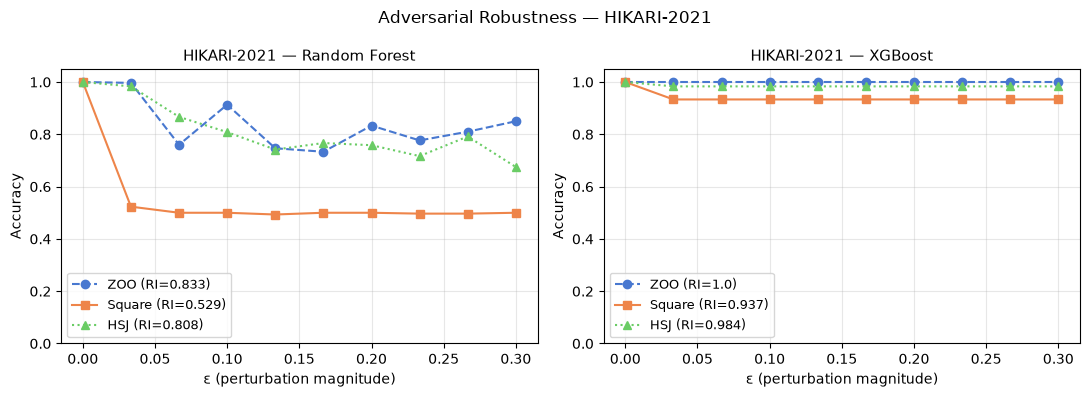

Saved: figures/hikari_robustness_curves.png


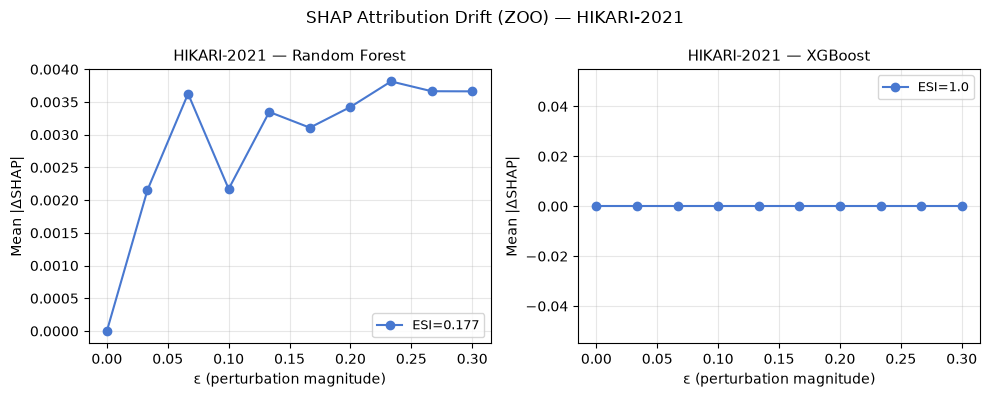

Saved: figures/hikari_esi_drift.png


In [10]:
# ── Figures ────────────────────────────────────────────────────────────────────
import os
os.makedirs('figures', exist_ok=True)

# Robustness curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, az, asq, ahsj, rz, rs, rh, title in [
    (axes[0], accs_rf_zoo,  accs_rf_sq,  accs_rf_hsj,
              ri_rf_zoo,    ri_rf_sq,    ri_rf_hsj,  'Random Forest'),
    (axes[1], accs_xgb_zoo, accs_xgb_sq, accs_xgb_hsj,
              ri_xgb_zoo,   ri_xgb_sq,   ri_xgb_hsj, 'XGBoost'),
]:
    ax.plot(EPSILONS, az,  'o--', color='#4878D0', label=f'ZOO (RI={rz})')
    ax.plot(EPSILONS, asq, 's-',  color='#EE854A', label=f'Square (RI={rs})')
    ax.plot(EPSILONS, ahsj, '^:', color='#6ACC65', label=f'HSJ (RI={rh})')
    ax.set_title(f'HIKARI-2021 — {title}', fontsize=11)
    ax.set_xlabel('ε (perturbation magnitude)')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Adversarial Robustness — HIKARI-2021', fontsize=12)
fig.tight_layout()
plt.savefig('figures/hikari_robustness_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/hikari_robustness_curves.png')

# ESI drift curves
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, drift, esi, title in [
    (axes[0], drift_rf,  esi_rf,  'Random Forest'),
    (axes[1], drift_xgb, esi_xgb, 'XGBoost'),
]:
    ax.plot(EPSILONS, drift, 'o-', color='#4878D0', label=f'ESI={esi}')
    ax.set_title(f'HIKARI-2021 — {title}', fontsize=11)
    ax.set_xlabel('ε (perturbation magnitude)')
    ax.set_ylabel('Mean |ΔSHAP|')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('SHAP Attribution Drift (ZOO) — HIKARI-2021', fontsize=12)
fig.tight_layout()
plt.savefig('figures/hikari_esi_drift.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/hikari_esi_drift.png')